In [ ]:
#LOADING LIBRARIES

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
# Load the dataset

In [51]:
df = pd.read_csv("AirPassengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
# Visualize the data

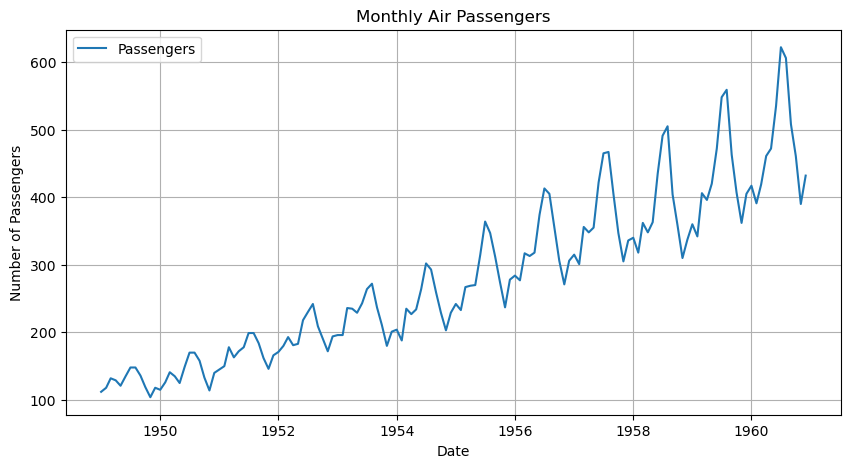

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(df, label='Passengers')
plt.title('Monthly Air Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid()
plt.show()


In [ ]:
#NORMALIZE THE DATA

In [33]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['#Passengers']])


In [ ]:
#PREPARE DATA FOR LSTM MODEL

In [35]:
def create_sequences(data, time_steps=12):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_steps = 12
X, y = create_sequences(scaled_data, time_steps)

# Reshape X for LSTM [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))


In [ ]:
#MODEL BUILDING

In [37]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#TRAIN THE MODEL

In [39]:
model.fit(X, y, epochs=100, batch_size=16, verbose=1)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1954
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1251
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0562
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0172 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0181 
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0132 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0130 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0103 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0100
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0088
Epoch 13/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 
Epoch 14/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 
Epoch 15/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0096 
Epoch 16/100
9/9 ━━━

In [ ]:
#FORECASTING

In [45]:
# Start with the last time_steps from the training data
last_sequence = scaled_data[-time_steps:]
forecast = []

current_input = last_sequence.reshape(1, time_steps, 1)

for _ in range(12):  # predict next 12 months
    next_val = model.predict(current_input, verbose=0)
    forecast.append(next_val[0, 0])
    
    # update the input sequence
    next_val_reshaped = next_val.reshape(1, 1, 1)  # Make it 3D: (1, 1, 1)
    current_input = np.append(current_input[:, 1:, :], next_val_reshaped, axis=1)


# Inverse transform to get actual values
forecast_actual = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))


In [ ]:
#PLOT 

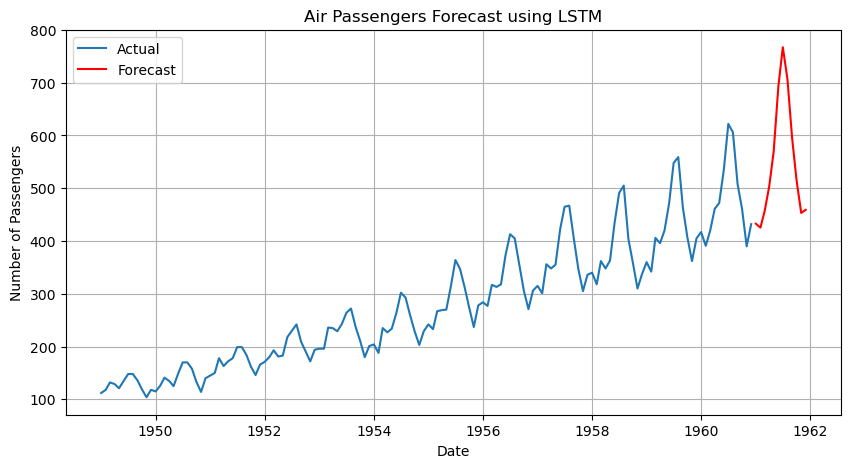

In [49]:
# Prepare forecast timeline
forecast_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['#Passengers'], label='Actual')
plt.plot(forecast_dates, forecast_actual, color='red', label='Forecast')
plt.title('Air Passengers Forecast using LSTM')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid()
plt.show()
